# Post-process charge data

## Install and import packages

In [1]:
!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import os

## Utils

In [3]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behaviour with the original dataset
REASSIGN_CHARGE_MODE = False

In [90]:
# Set SAVE equals to True, in order to Save cleaned charge data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin1/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [41]:
#### Load charge data
#charge_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 1200
#charge_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
charge_data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#charge_data = pd.read_csv(f'.//Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')


# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970 entries, 0 to 1969
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             1970 non-null   int64  
 1   charge_mode       1970 non-null   int64  
 2   duration_minutes  1970 non-null   float64
 3   km_driven         1970 non-null   float64
 4   charge            1970 non-null   float64
 5   id                1970 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 92.5 KB


In [42]:
charge_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,1,1,164.324351,3.418540,6.766047,12
1,1,1,120.692406,6.017137,-1.969588,34
2,1,1,168.987688,2.690132,3.509992,46
3,1,1,293.811498,2.054488,10.956823,47
4,1,1,252.395798,4.229441,6.187888,50
5,1,1,454.378285,2.108616,17.703405,53
6,1,2,156.067755,10.642430,15.917313,67
7,1,1,331.270165,2.573385,12.943484,75
8,1,1,168.724340,2.326434,3.074245,102
9,1,1,162.013291,2.304303,0.400413,104


### Data description

In [43]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [44]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

print("\n🔍 Records with missing values:\n")

records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

🔍 Records with missing values:



In [45]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['duration_minutes', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,1970.0,325.414512,181.014482,96.639728,182.610924,278.638093,412.215698,1095.586784
delta_soc,1970.0,15.931266,10.435222,-12.145306,7.668375,15.959827,23.758531,41.368745


In [46]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

🔋 Statistics on charge:
 count    1970.000000
mean       15.931266
std        10.435222
min       -12.145306
25%         7.668375
50%        15.959827
75%        23.758531
max        41.368745
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count    1970.000000
mean       19.384087
std       234.850364
min     -8243.454479
25%        14.157363
50%        22.657001
75%        30.074509
max      3614.996373
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    1970.000000
mean        0.051733
std         0.043955
min        -0.082523
25%         0.031138
50%         0.041912
75%         0.062274
max         0.314384
Name: charge_per_min, dtype: float64


In [47]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [48]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [49]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [50]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [51]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [52]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [53]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 103


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
1,1,1,120.692406,6.017137,-1.969588,34,-1.969588,-61.278002,-0.016319
54,1,1,218.285100,7.093472,-1.092600,459,-1.092600,-199.785050,-0.005005
76,1,1,171.171069,10.923496,-3.592480,661,-3.592480,-47.647054,-0.020988
84,1,2,183.634238,32.503167,-3.476872,701,-3.476872,-52.815932,-0.018934
86,1,1,216.528736,21.051532,-5.976646,709,-5.976646,-36.229137,-0.027602
...,...,...,...,...,...,...,...,...,...
1907,1,1,123.711085,2.687944,-2.451611,13214,-2.451611,-50.461139,-0.019817
1924,1,2,132.013943,6.171353,-1.033034,13332,-1.033034,-127.792474,-0.007825
1952,1,1,126.807484,5.370623,-0.537182,13513,-0.537182,-236.060357,-0.004236
1959,1,1,124.606271,7.058741,-6.378195,13541,-6.378195,-19.536291,-0.051187


In [54]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [56]:
# Identify records with high charge per minute
###########################
MAX_CHARGE_PER_MIN = 1.10 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [57]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [58]:
# Identify records with low charge per minute
###########################
MIN_CHARGE_PER_MIN = 0.005 #
###########################


anomalous_charge_records = charge_data[(charge_data['charge_per_min'] < MIN_CHARGE_PER_MIN)]

length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute < {MIN_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute < 0.005: 24


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
8,1,1,162.013291,2.304303,0.400413,104,0.400413,404.615964,0.002471
53,1,1,118.640240,3.385326,0.070615,466,0.070615,1680.107897,0.000595
120,1,1,218.726866,22.996584,0.247680,970,0.247680,883.103089,0.001132
172,1,2,138.020920,3.104448,0.329232,1297,0.329232,419.220358,0.002385
231,1,1,226.141986,5.837213,0.062557,1759,0.062557,3614.996373,0.000277
669,1,1,174.247449,4.358501,0.500781,5067,0.500781,347.951281,0.002874
703,1,1,124.284316,2.801419,0.272816,5307,0.272816,455.561554,0.002195
746,1,1,100.056144,3.340609,0.309021,5605,0.309021,323.783997,0.003088
951,1,2,239.393294,12.990770,0.902895,7059,0.902895,265.139629,0.003772
1001,1,2,243.799914,27.541295,0.795832,7479,0.795832,306.346051,0.003264


In [59]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [60]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843 entries, 0 to 1842
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    1843 non-null   int64  
 1   charge_mode              1843 non-null   int64  
 2   duration_minutes         1843 non-null   float64
 3   km_driven                1843 non-null   float64
 4   charge                   1843 non-null   float64
 5   id                       1843 non-null   int64  
 6   delta_soc                1843 non-null   float64
 7   min_per_perc_of_battery  1843 non-null   float64
 8   charge_per_min           1843 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 129.7 KB


In [61]:
#Print statistics
print('Statistics after post-processing')
print("\n🔋 Statistics on charge:\n", charge_data['charge'].describe())
print("\n🔋 Statistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\n🔋 Statistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

🔋 Statistics on charge:
 count    1843.000000
mean       17.204577
std         9.519609
min         0.626788
25%         9.107282
50%        17.059407
75%        24.256345
max        41.368745
Name: charge, dtype: float64

🔋 Statistics on min_per_perc_of_battery:
 count    1843.000000
mean       26.760624
std        22.490065
min         3.180822
25%        15.502475
50%        23.016781
75%        30.317937
max       199.518901
Name: min_per_perc_of_battery, dtype: float64

🔋 Statistics on charge_per_min:
 count    1843.000000
mean        0.056469
std         0.041119
min         0.005012
25%         0.032984
50%         0.043447
75%         0.064506
max         0.314384
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [62]:
if REASSIGN_CHARGE_MODE:
    # Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in chrge_mode
    result = charge_data.groupby("charge_mode")["charge_per_min"].max()
    print(result)

In [79]:
if REASSIGN_CHARGE_MODE:
    # ORIGINAL Thresholds
    max_120 = 0.04
    max_240 = 0.16
    
    
    # Conditions
    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]
    
    # Values to assign
    values = [1, 2]
    
    # Default value if none of the conditions match
    charge_data['charge_mode'] = np.select(conditions, values, default=3)
    
    charge_data.head(30)

## Data Visualization and Comparative Analysis

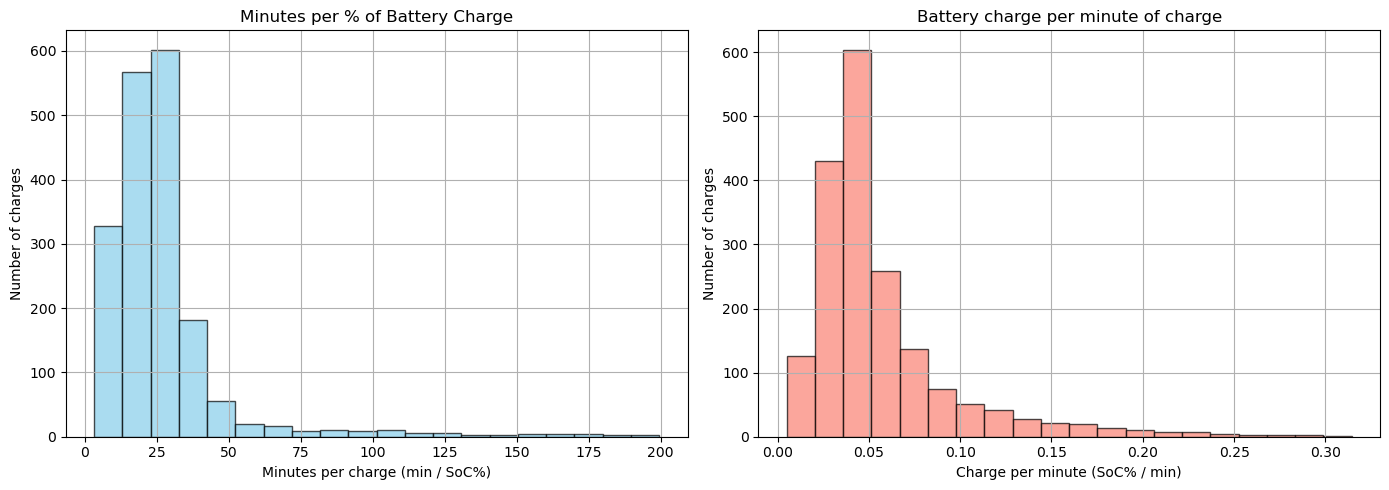

In [80]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [81]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
0,1,2,164.324351,3.418540,6.766047,12,6.766047,24.286610,0.041175,0,6.766047
1,1,1,168.987688,2.690132,3.509992,46,3.509992,48.144754,0.020771,0,3.509992
2,1,1,293.811498,2.054488,10.956823,47,10.956823,26.815390,0.037292,0,10.956823
3,1,1,252.395798,4.229441,6.187888,50,6.187888,40.788683,0.024517,0,6.187888
4,1,1,454.378285,2.108616,17.703405,53,17.703405,25.666152,0.038962,0,17.703405


In [82]:
max_min = charge_data['min_per_perc_of_battery'].max()
max_min_row = charge_data[charge_data['min_per_perc_of_battery'] == max_min]

print("\n Record with maximum min/SoC:\n")
max_min_row.head()


 Record with maximum min/SoC:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
1719,1,1,135.373894,3.420997,0.678502,12791,0.678502,199.518901,0.005012,0,0.678502


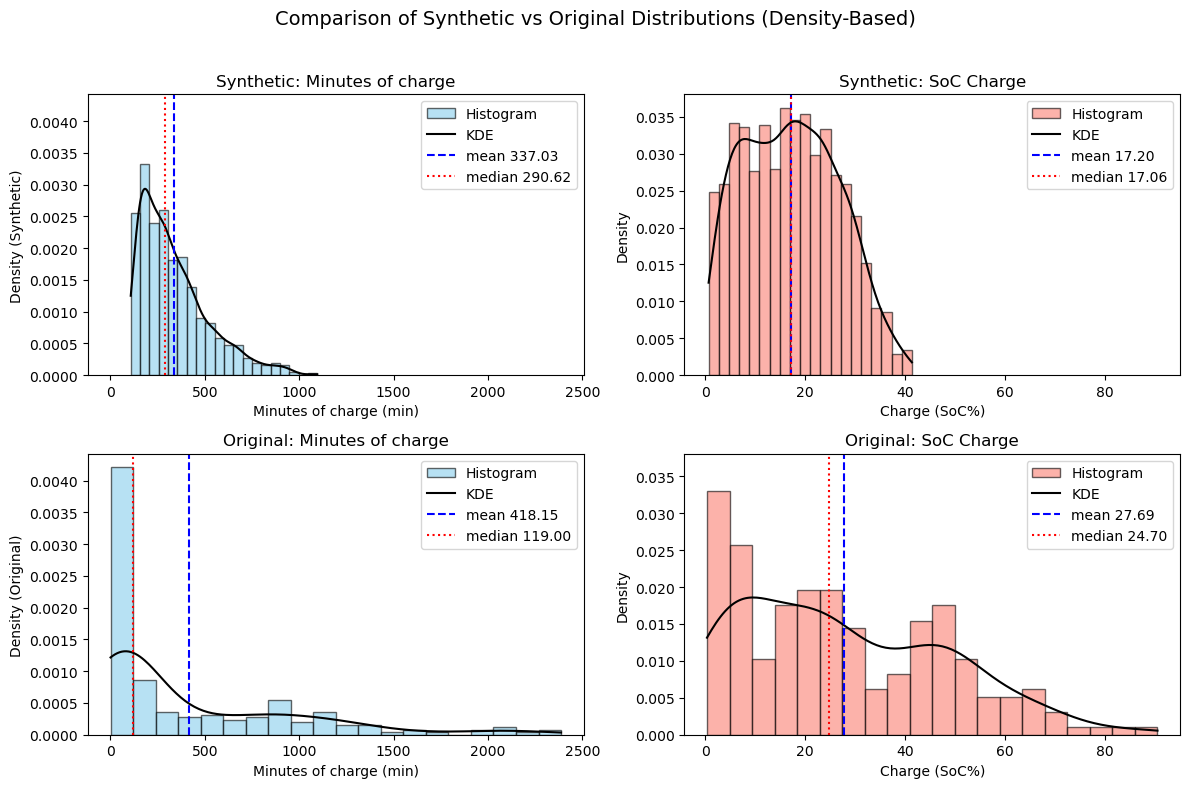

In [83]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=density,
                                   alpha=0.6, color=color, edgecolor='black', label='Histogram')

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Charge', xlabel='Charge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(charge_data_original.get('duration_minutes', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data_original.get('charge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Charge', xlabel='Charge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

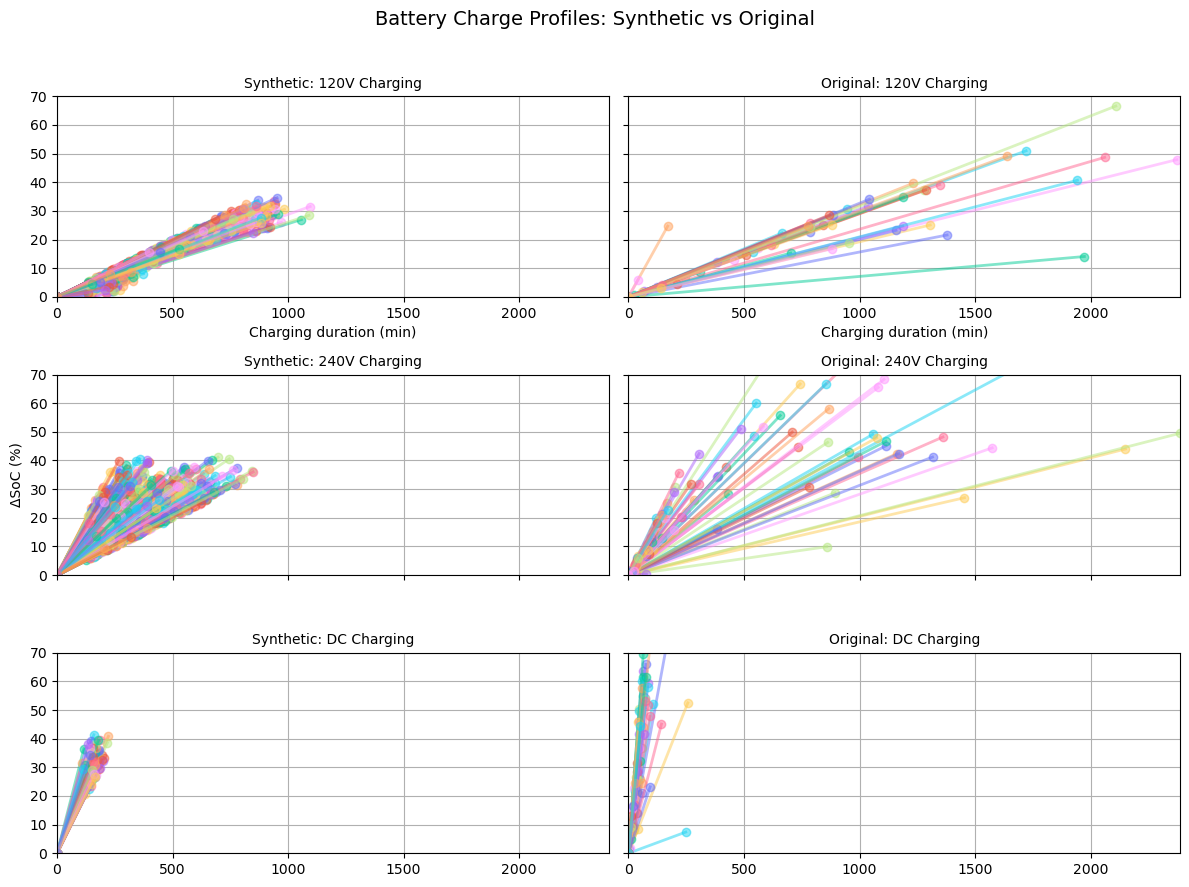

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

# --- Synthetic data prep ---
charge_data = charge_data.copy()
charge_data['delta_soc'] = charge_data['charge']  # already ΔSoC
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['delta_soc']

# --- Original data prep ---
charge_data_original = charge_data_original.copy()
charge_data_original['delta_soc'] = (
    charge_data_original['end_soc'] - charge_data_original['soc']
)
charge_data_original['soc'] = 0
charge_data_original['end_soc'] = charge_data_original['delta_soc']

# --- Shared scales ---
max_minutes = max(
    charge_data['duration_minutes'].max(),
    charge_data_original['duration_minutes'].max()
)
max_soc = 70  # y-limit

# --- Colors ---
colors = px.colors.qualitative.Plotly
n_colors = len(colors)

# --- Mode mapping ---
mode_titles = {
    '120': ('Synthetic: 120V Charging', 'Original: 120V Charging'),
    '240': ('Synthetic: 240V Charging', 'Original: 240V Charging'),
    'DC':  ('Synthetic: DC Charging', 'Original: DC Charging')
}

# --- Figure setup ---
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 9),
    sharex=True, sharey=True
)

# --- Loop through modes ---
for i, (key, (title_syn, title_orig)) in enumerate(mode_titles.items()):

    # --- Filter synthetic (numeric codes) ---
    if key == 'DC':
        syn = charge_data[charge_data['charge_mode'] == 3]
    elif key == '120':
        syn = charge_data[charge_data['charge_mode'] == 1]
    elif key == '240':
        syn = charge_data[charge_data['charge_mode'] == 2]

    # --- Filter original (string-based modes) ---
    if key == 'DC':
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
        ]
    else:
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains(key, case=False, na=False)
        ]

    # --- LEFT: Synthetic ---
    ax_syn = axes[i, 0]
    for j, (_, row) in enumerate(syn.iterrows()):
        ax_syn.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_syn.set_title(title_syn, fontsize=10)
    ax_syn.grid(True)
    ax_syn.set_xlim(0, max_minutes)
    ax_syn.set_ylim(0, max_soc)
    if i == 1:
        ax_syn.set_ylabel("ΔSoC (%)")

    # --- RIGHT: Original ---
    ax_orig = axes[i, 1]
    for j, (_, row) in enumerate(orig.iterrows()):
        ax_orig.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_orig.set_title(title_orig, fontsize=10)
    ax_orig.grid(True)
    ax_orig.set_xlim(0, max_minutes)
    ax_orig.set_ylim(0, max_soc)

# --- Shared ----
for ax in axes[0, :]:
    ax.set_xlabel("Charging duration (min)")
    ax.tick_params(labelbottom=True)

fig.suptitle("Battery Charge Profiles: Synthetic vs Original", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [85]:
charge_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
0,1,2,164.324351,3.418540,6.766047,12,6.766047,24.286610,0.041175,0,6.766047
1,1,1,168.987688,2.690132,3.509992,46,3.509992,48.144754,0.020771,0,3.509992
2,1,1,293.811498,2.054488,10.956823,47,10.956823,26.815390,0.037292,0,10.956823
3,1,1,252.395798,4.229441,6.187888,50,6.187888,40.788683,0.024517,0,6.187888
4,1,1,454.378285,2.108616,17.703405,53,17.703405,25.666152,0.038962,0,17.703405


In [86]:
charge_data['charge_per_min'].describe()

count    1843.000000
mean        0.056469
std         0.041119
min         0.005012
25%         0.032984
50%         0.043447
75%         0.064506
max         0.314384
Name: charge_per_min, dtype: float64

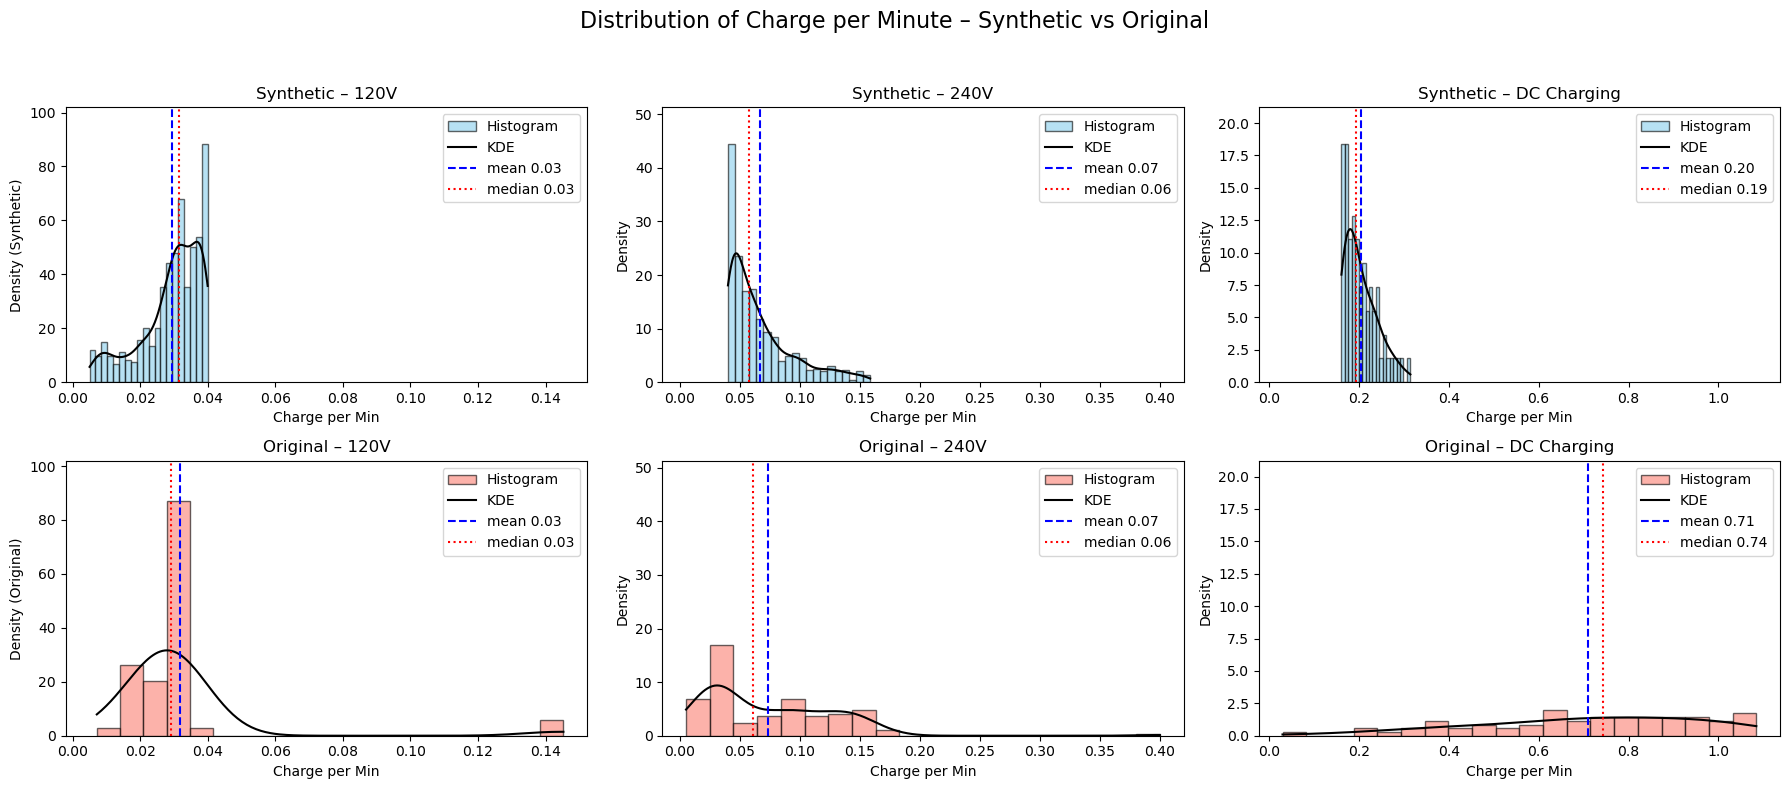

In [87]:
# --- Distribution of Charge per Min: Synthetic vs Original ---

# Map charge_mode values to labels
charge_labels = {1: "120V", 2: "240V", 3: "DC Charging"}

# Figure setup: 2 rows (synthetic/original) × 3 columns (charge modes)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # no sharex or sharey now

for i, mode in enumerate([1, 2, 3]):
    # --- Synthetic ---
    data_syn = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax_syn = axes[0, i]
    plot_hist_with_kde(
        data_syn,
        ax=ax_syn,
        color='skyblue',
        title=f"Synthetic – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Original ---
    if mode == 3:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
    else:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains(str(mode), case=False, na=False)
    data_orig = charge_data_original.loc[mask_orig, 'charge_per_min']

    ax_orig = axes[1, i]
    plot_hist_with_kde(
        data_orig,
        ax=ax_orig,
        color='salmon',
        title=f"Original – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Smart x-axis per column ---
    all_data = pd.concat([data_syn, data_orig]).dropna()
    if not all_data.empty:
        xmin, xmax = all_data.min(), all_data.max()
        xmargin = (xmax - xmin) * 0.05
        ax_syn.set_xlim(xmin - xmargin, xmax + xmargin)
        ax_orig.set_xlim(xmin - xmargin, xmax + xmargin)

    # --- Smart y-axis per column ---
    ymax_vals = [ax_syn.get_ylim()[1], ax_orig.get_ylim()[1]]
    ymax = max(ymax_vals) * 1.1  # 10% padding
    ax_syn.set_ylim(0, ymax)
    ax_orig.set_ylim(0, ymax)

# --- Common labels ---
axes[0, 0].set_ylabel('Density (Synthetic)')
axes[1, 0].set_ylabel('Density (Original)')

fig.suptitle("Distribution of Charge per Minute – Synthetic vs Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


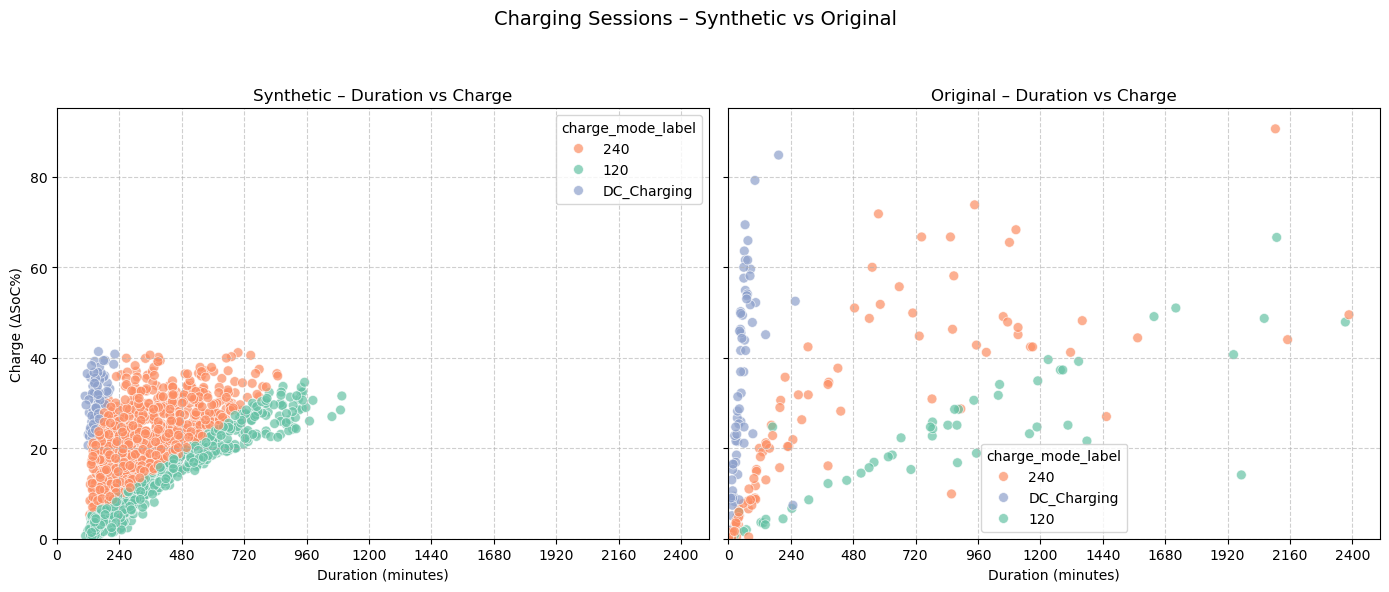

In [88]:
# --- Copy to avoid modifying originals ---
charge_data_syn = charge_data.copy()
charge_data_orig = charge_data_original.copy()

# --- Normalize charge_mode labels for consistency ---
def normalize_label_syn(val):
    if val == 1:
        return '120'
    elif val == 2:
        return '240'
    elif val == 3:
        return 'DC_Charging'
    else:
        return None

def normalize_label_orig(val):
    s = str(val).strip().lower()
    if 'dc' in s:
        return 'DC_Charging'
    elif '120' in s:
        return '120'
    elif '240' in s:
        return '240'
    else:
        return None

charge_data_syn['charge_mode_label'] = charge_data_syn['charge_mode'].apply(normalize_label_syn)
charge_data_orig['charge_mode_label'] = charge_data_orig['charge_mode'].apply(normalize_label_orig)

# --- Define consistent color palette ---
fixed_palette = {
    "120": "#66c2a5",        # greenish
    "240": "#fc8d62",        # orange
    "DC_Charging": "#8da0cb" # blue
}

# --- Shared axis limits for fair comparison ---
max_duration = max(
    charge_data_syn['duration_minutes'].max(),
    charge_data_orig['duration_minutes'].max()
)
max_charge = max(
    charge_data_syn['charge'].max(),
    charge_data_orig['charge'].max()
)

# --- Create side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ==========================================================
# LEFT: Synthetic
# ==========================================================
sns.scatterplot(
    data=charge_data_syn,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Synthetic – Duration vs Charge", fontsize=12)
axes[0].set_xlim(0, max_duration * 1.05)
axes[0].set_ylim(0, max_charge * 1.05)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Charge (ΔSoC%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(60))

# ==========================================================
# RIGHT: Original
# ==========================================================
sns.scatterplot(
    data=charge_data_orig,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Original – Duration vs Charge", fontsize=12)
axes[1].set_xlim(0, max_duration * 1.05)
axes[1].set_ylim(0, max_charge * 1.05)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(240))



# --- Final layout ---
fig.suptitle("Charging Sessions – Synthetic vs Original", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [89]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843 entries, 0 to 1842
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    1843 non-null   int64  
 1   charge_mode              1843 non-null   int64  
 2   duration_minutes         1843 non-null   float64
 3   km_driven                1843 non-null   float64
 4   charge                   1843 non-null   float64
 5   id                       1843 non-null   int64  
 6   delta_soc                1843 non-null   float64
 7   min_per_perc_of_battery  1843 non-null   float64
 8   charge_per_min           1843 non-null   float64
 9   soc                      1843 non-null   int64  
 10  end_soc                  1843 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 158.5 KB


## Original dataset

In [31]:
#charge_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
charge_data_original = pd.read_csv('./datasets/EV_data.csv')

charge_data_original = charge_data_original[charge_data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          224 non-null    float64
 1   timestamp    224 non-null    object 
 2   end_time     224 non-null    object 
 3   odo          224 non-null    float64
 4   end_odo      224 non-null    float64
 5   soc          224 non-null    float64
 6   end_soc      224 non-null    float64
 7   event        224 non-null    object 
 8   charge_mode  224 non-null    object 
dtypes: float64(5), object(4)
memory usage: 15.9+ KB


In [32]:
# Count number of entries for each charge_mode
counts = charge_data_original['charge_mode'].value_counts()
print(counts)

charge_mode
240           99
DCCharging    75
120           50
Name: count, dtype: int64


In [33]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['charge'] = charge_data_original['end_soc'] - charge_data_original['soc']
charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\n🔋 Statistics on Charge:\n", charge_data_original['charge'].describe())

Number of rows after removing duplicates: 224

🔋 Statistics on Charge:
 count    224.000000
mean      27.886607
std       20.374474
min        0.300000
25%        9.000000
50%       24.700000
75%       44.325000
max       90.600000
Name: charge, dtype: float64


In [34]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)


In [35]:
MAX_CHARGE_PER_MIN = 1.10
##########################################################



anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 9


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,charge,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
16,-8.996320e+18,2021-01-15 14:05:00,2021-01-15 14:34:00,6380.484375,6380.484375,30.5,65.4,charge,DCCharging,34.9,-34.9,29.0,0.830946,1.203448
105,-8.996320e+18,2021-04-15 13:54:00,2021-04-15 14:14:00,19160.515630,19160.515630,24.3,53.3,charge,DCCharging,29.0,-29.0,20.0,0.689655,1.450000
112,-8.996320e+18,2021-04-18 14:40:00,2021-04-18 14:55:00,19712.149030,19712.149030,39.2,58.8,charge,DCCharging,19.6,-19.6,15.0,0.765306,1.306667
119,-8.996320e+18,2021-04-25 14:48:00,2021-04-25 15:19:00,20790.796880,20790.796880,12.9,52.1,charge,DCCharging,39.2,-39.2,31.0,0.790816,1.264516
120,-8.996320e+18,2021-04-26 23:32:00,2021-04-27 00:09:00,20932.529370,20932.529370,11.3,57.2,charge,DCCharging,45.9,-45.9,37.0,0.806100,1.240541
125,-8.996320e+18,2021-05-02 10:04:00,2021-05-02 10:17:00,21604.906250,21604.906250,18.0,32.5,charge,DCCharging,14.5,-14.5,13.0,0.896552,1.115385
157,-8.996320e+18,2021-05-25 20:01:00,2021-05-25 20:35:00,26702.984380,26703.000000,23.5,62.7,charge,DCCharging,39.2,-39.2,34.0,0.867347,1.152941
199,-8.996320e+18,2021-06-30 13:52:00,2021-06-30 14:04:00,34227.500000,34227.500000,21.5,36.0,charge,DCCharging,14.5,-14.5,12.0,0.827586,1.208333
213,-8.996320e+18,2021-07-25 21:05:00,2021-07-25 21:49:00,38327.546880,38327.546880,19.6,76.0,charge,DCCharging,56.4,-56.4,44.0,0.780142,1.281818


In [36]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      215 non-null    float64       
 1   timestamp                215 non-null    datetime64[ns]
 2   end_time                 215 non-null    datetime64[ns]
 3   odo                      215 non-null    float64       
 4   end_odo                  215 non-null    float64       
 5   soc                      215 non-null    float64       
 6   end_soc                  215 non-null    float64       
 7   event                    215 non-null    object        
 8   charge_mode              215 non-null    object        
 9   charge                   215 non-null    float64       
 10  discharge                215 non-null    float64       
 11  duration_minutes         215 non-null    float64       
 12  min_per_perc_of_battery  215 non-nul

In [37]:
charge_data_original['charge_per_min'].describe()

count    215.000000
mean       0.268711
std        0.328554
min        0.005128
25%        0.032555
50%        0.103226
75%        0.466356
max        1.084375
Name: charge_per_min, dtype: float64

In [38]:
# Print max charge_data_original['charge_per_min'] when '120' is in charge_data_original['charge_mode'], when '240' is in charge_mode and when 'DC' is in charge_mode
result = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(result)

charge_mode
120           0.145294
240           0.400000
DCCharging    1.084375
Name: charge_per_min, dtype: float64


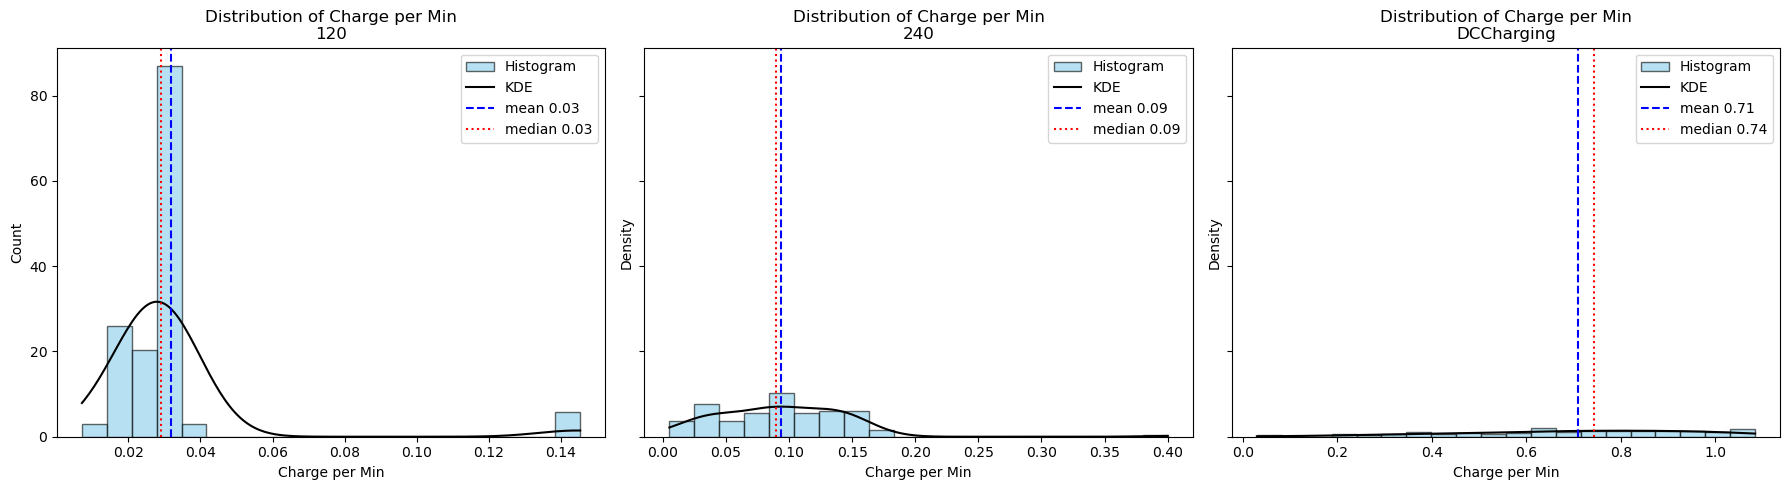

In [39]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()


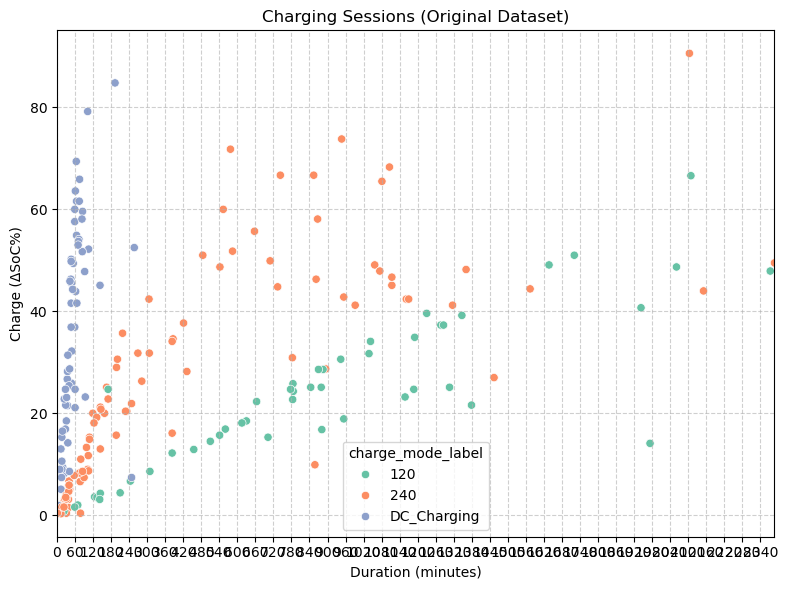

In [40]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker

# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}

charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

# Define consistent color palette (matching Set2)
fixed_palette = {
    "120": "#66c2a5",       # greenish
    "240": "#fc8d62",       # orange
    "DC_Charging": "#8da0cb" # blue
}

# Define desired order for hues
hue_order = ["120", "240", "DC_Charging"]

# Compute derived features
max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    hue_order=hue_order,     # ← Force order
    palette=fixed_palette,   # ← Consistent colors
    legend="auto"
)

plt.title("Charging Sessions (Original Dataset)")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (ΔSoC%)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(60))
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Save data

In [91]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_path_csv, index=False)

## Merge

In [92]:
'''# TAKE DATA 
#data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_1EVpenalty/Generated_data/epoch_1800/EV_generated_data_1800.csv')
number = 1200
data = pd.read_csv(f'./Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
#data =  pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

# print columns
print(data.columns)

# load also trip_Data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin1/EV_generated_data__trip_cleaned.csv') 

#take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
trip_data = trip_data[['id']]
charge_data_1 = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin1/EV_generated_data__charge_cleaned.csv')

# take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
charge_data_1 = charge_data_1[[ 'id']]


# keep rows that are present in ids of trip_data and charge_data
data['id'] = data.index

data = data[data['id'].isin(trip_data['id']) | data['id'].isin(charge_data_1['id'])]

#drop columns 'id'
data = data.drop(columns=['id'])

#when event = 1 --> set end_odo = odo 
#data.loc[data['event'] == 1, 'end_odo'] = data['odo']
data.loc[data['event'] == 1, 'km_driven'] = 0

# add in first position column 'vin', all rows with value -2.47174E+18 or -1.12313E+18
data.insert(0, 'vin', -2.47174E+18)

# map event 0 -> trip, 1 -> charge
data['event'] = data['event'].map({0: 'trip', 1: 'charge'})

# map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})
data.to_csv('./Data_saved/kl_scheduling/allRows_vin1/EV_generated_data_cleaned.csv', index=False)'''

Index(['event', 'charge_mode', 'duration_minutes', 'km_driven', 'charge'], dtype='object')


In [ ]:
charge_data.info()